In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Step 1: Generate synthetic data for classification
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=2,
    random_state=42
)

In [2]:
# Step 2: Train a classifier (Logistic Regression)
clf = LogisticRegression(max_iter=1000, solver='liblinear')

# Step 3: Perform Cross-Validation
n_folds = 5
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

train_aucs = []
test_aucs = []

for train_index, test_index in cv.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    clf.fit(X_train, y_train)

    # Predict probabilities rather than classes
    y_train_proba = clf.predict_proba(X_train)[:, 1]
    y_test_proba = clf.predict_proba(X_test)[:, 1]

    # Calculate AUC-ROC
    train_aucs.append(roc_auc_score(y_train, y_train_proba))
    test_aucs.append(roc_auc_score(y_test, y_test_proba))

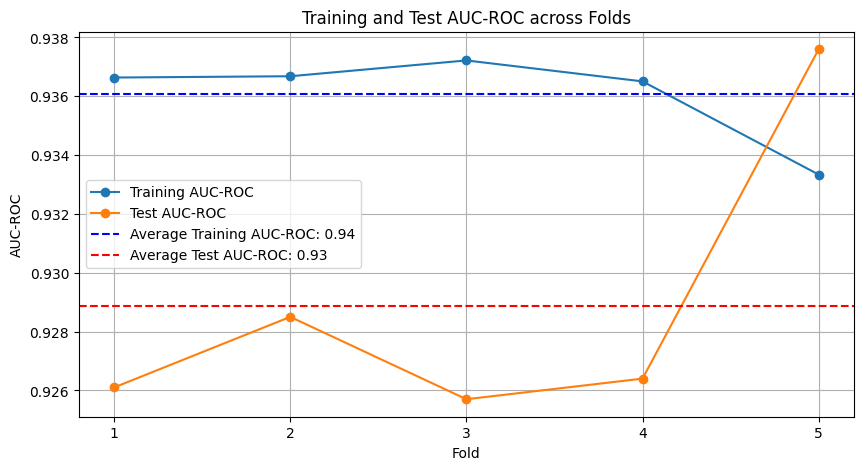

In [3]:
# Step 4: Calculate average AUC-ROC
avg_train_auc = np.mean(train_aucs)
avg_test_auc = np.mean(test_aucs)

# Step 5: Visualize results
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_folds + 1), train_aucs, label='Training AUC-ROC', marker='o')
plt.plot(range(1, n_folds + 1), test_aucs, label='Test AUC-ROC', marker='o')

plt.axhline(
    y=avg_train_auc,
    color='b',
    linestyle='--',
    label=f'Average Training AUC-ROC: {avg_train_auc:.2f}'
)

plt.axhline(
    y=avg_test_auc,
    color='r',
    linestyle='--',
    label=f'Average Test AUC-ROC: {avg_test_auc:.2f}'
)

plt.xlabel('Fold')
plt.ylabel('AUC-ROC')
plt.title('Training and Test AUC-ROC across Folds')
plt.legend()
plt.xticks(range(1, n_folds + 1))
plt.grid(True)
plt.show()